# Project Setup

In [1]:
# Load Necessary Packages

# Base modules
import pandas as pd 
import numpy as np

# API Modules
import requests
import time
import os
from tqdm import tqdm 

# Plotting
from PIL import Image
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import geopandas as gpd
from shapely.geometry import Point, Polygon


# Modeling
from sklearn.cluster import KMeans

# Project Topic

### Project Explanation

 This projct is a data mining project, where I will be conducting an unsupervised machine learning task.

### Project Goal

This project aims to identify hot spots of bear activity. 

I find this topic interesting as I often venture into the outdoors often encounter wildlife, including bears. The results of this analysis could help park employees find areas to add warnings and infrastructure such as bear proof trashcans and bear lockers.

I aim to hone my skills in data mining and machine learning throughout this project.

# Data

The data I used for this project was acquired through iNaturalist, a wildlife observation website: https://www.inaturalist.org/pages/api+reference. 

##### Set Parameters of the API Calls

In [2]:
# Set the location
location=34 # This is colorado


# Dictionary of taxon IDs
taxon_id_dict = {'black_bear': 41638} 


taxon_list = globals()["taxon_id_dict"]
taxon_list['black_bear']

41638

In [3]:
# Parameters for the API Call
params = {
    "per_page": 200,          
    "page": 1 
}

##### Make API calls to get images of each species

See this link for help building the URL: https://api.inaturalist.org/v1/docs/#!/Observations/get_observations_observers

In [4]:
# Create an empty data frame to store the data
species_df = pd.DataFrame()

# Clean the taxon name for the URL
for taxon_name in taxon_list:

    taxon_id=taxon_list[taxon_name]

    # Base URL for given species and location
    base_url = f"https://api.inaturalist.org/v1/observations?captive=false&photos=true&quality_grade=research&place_id={location}&taxon_id={taxon_id}"

    # Create a list to store all results
    observations = []

    # Loop through pages
    while True:
        
        # Get the response
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print("Error:", response.status_code)
            break
        
        # Get the data
        data = response.json()
        results = data.get("results", [])

        # Break the loop if no results are returned
        if not results:
            print("No more results found.")
            break
        
        # Append results to the observations list
        for result in results:
            # Extract relevant fields
            obs = {
                "species_guess": result["species_guess"],
                "taxon_id": result["taxon"]["id"] if result["taxon"] else None,
                "common_name": result["taxon"]["common_name"]["name"] if result["taxon"] and result["taxon"].get("common_name") else None,
                "latitude": result["geojson"]["coordinates"][1] if result.get("geojson") else None,
                "longitude": result["geojson"]["coordinates"][0] if result.get("geojson") else None,
                "observed_on": result["observed_on"]
            }
            observations.append(obs)

        print(f"Fetched {len(results)} results from page {params['page']}. Total observations: {len(observations)}")

        # Increment the page parameter for the next request
        params["page"] += 1

        # Give the API a break 
        time.sleep(1)

    # Store that species in a temporary data frame
    df_temp = pd.DataFrame(observations)

    df_temp['common_name'] = taxon_name

    # Give the API a break 
    time.sleep(1)

    # Concatenate with the main data frame
    df_raw = pd.concat([species_df, df_temp], ignore_index=True)

# After looping through species, you can output the final DataFrame
print("Final species DataFrame:")


Fetched 200 results from page 1. Total observations: 200
Fetched 200 results from page 2. Total observations: 400
Fetched 200 results from page 3. Total observations: 600
Fetched 200 results from page 4. Total observations: 800
Fetched 200 results from page 5. Total observations: 1000
Fetched 200 results from page 6. Total observations: 1200
Fetched 83 results from page 7. Total observations: 1283
No more results found.
Final species DataFrame:


# Data Prep + EDA

#### Check Dataset Dimensions

In [5]:
# Dimensions
print(df_raw.shape)

# Dimensions without duplicates
print(df_raw.drop_duplicates().shape)

# Drop duplicates
df_raw = df_raw.drop_duplicates()

(1283, 6)
(1273, 6)


In [6]:
# Take a look at the dataset
df_raw.head()

,species_guess,taxon_id,common_name,latitude,longitude,observed_on
0,American Black Bear,41638,black_bear,40.011317,-105.282844,2024-10-23
1,American Black Bear,41638,black_bear,39.006993,-104.889382,2024-06-11
2,American Black Bear,41638,black_bear,39.004571,-104.893298,2024-09-05
3,Amerikanischer Schwarzbär,41638,black_bear,39.006594,-104.889996,2023-06-06
4,American Black Bear,41638,black_bear,39.733643,-105.434958,2024-11-20


#### Map

In [7]:
# Create a folium map centered around the mean coordinates
m = folium.Map(location=[df_raw['latitude'].mean(), 
                         df_raw['longitude'].mean()], zoom_start=6.4)

# Add heatmap
heat_data = list(zip(df_raw['latitude'], df_raw['longitude']))
HeatMap(heat_data).add_to(m)
m

In [8]:
# Copy the prepped data for modeling
model_df = df_raw.copy()

In [9]:
# Define a grid of the sightings
lat_min, lat_max = model_df['latitude'].min(), model_df['latitude'].max()
lon_min, lon_max = model_df['longitude'].min(), model_df['longitude'].max()

In [10]:
# Define the cells size
cell_size = 0.15

# Create grid cells
lat_bins = np.arange(lat_min, lat_max + cell_size, cell_size)
lon_bins = np.arange(lon_min, lon_max + cell_size, cell_size)

In [11]:
# Create bins for latitude and longitude
model_df['lat_bin'] = pd.cut(model_df['latitude'], bins=lat_bins, labels=lat_bins[:-1])
model_df['lon_bin'] = pd.cut(model_df['longitude'], bins=lon_bins, labels=lon_bins[:-1])

In [12]:
# Get the density counts
density_counts = model_df.groupby(['lat_bin', 'lon_bin']).size().reset_index(name='count')
density_counts['lat_bin'] = density_counts['lat_bin'].astype(float)
density_counts['lon_bin'] = density_counts['lon_bin'].astype(float)

C:\Users\polin\AppData\Local\Temp\ipykernel_17728\1584309166.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  density_counts = model_df.groupby(['lat_bin', 'lon_bin']).size().reset_index(name='count')


In [13]:
# Center of each grid cell
density_counts['latitude_center'] = density_counts['lat_bin'] + (cell_size / 2)
density_counts['longitude_center'] = density_counts['lon_bin'] + (cell_size / 2)

# Convert to GeoDataFrame
geometry = [Point(lon, lat) for lon, lat in zip(density_counts['longitude_center'], density_counts['latitude_center'])]
density_gdf = gpd.GeoDataFrame(density_counts, geometry=geometry)

# Drop  columns
density_gdf = density_gdf[['latitude_center', 'longitude_center', 'count', 'geometry']]

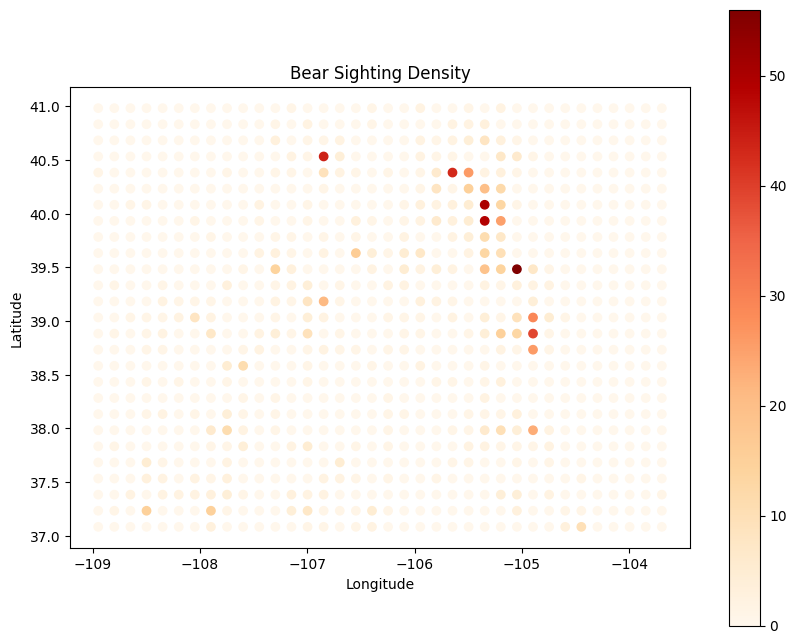

In [14]:
# Plot the density data
density_gdf.plot(column='count', cmap='OrRd', legend=True, figsize=(10, 8))
plt.title('Bear Sighting Density')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Modeling

#### Determine Optimal K

In [17]:
density_gdf.head(2)

,latitude_center,longitude_center,count,geometry
0,37.082596,-108.946972,0,POINT (-108.94697 37.0826)
1,37.082596,-108.796972,0,POINT (-108.79697 37.0826)


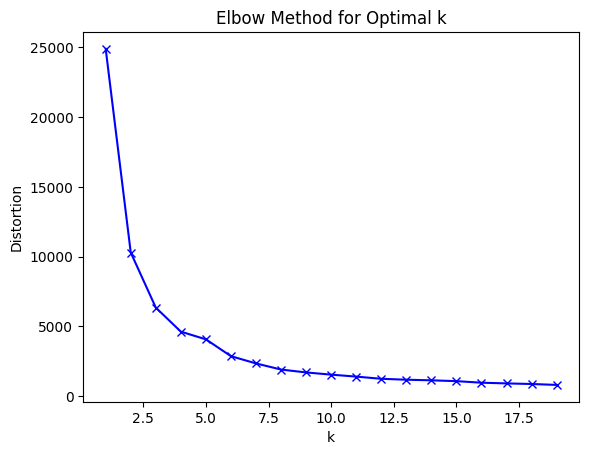

In [23]:
distortions = []
K = range(1, 20)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(density_gdf[['latitude_center', 'longitude_center', 'count']])
    distortions.append(kmeans.inertia_)

plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('Elbow Method for Optimal k')
plt.show()

#### Fit Model

In [24]:
k_optimal = 6  
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
density_gdf['cluster'] = kmeans.fit_predict(density_gdf[['latitude_center', 'longitude_center', 'count']])

#### Evaluate

In [26]:
# Evaluate the cluster centers
cluster_centers = kmeans.cluster_centers_
print(cluster_centers) 

[[  39.10057043 -107.86849115    0.35949367]
 [  39.88259575 -105.52197217   46.83333333]
 [  39.20759575 -105.81363883   18.44444444]
 [  40.10229914 -105.05650607    0.43220339]
 [  37.95361847 -105.21742671    0.32575758]
 [  38.98165235 -106.19602877    6.18867925]]


In [27]:
# Get count of sightings by clusters
cluster_counts = density_gdf.groupby('cluster')['count'].sum()
print(cluster_counts)

cluster
0    142
1    281
2    332
3    102
4     86
5    328
Name: count, dtype: int64


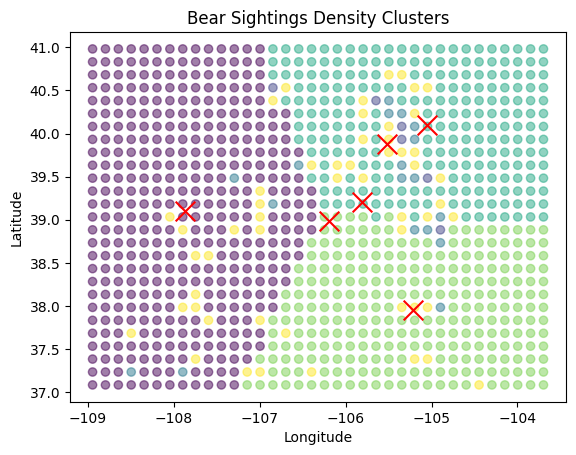

In [28]:
plt.scatter(density_gdf['longitude_center'], density_gdf['latitude_center'], c=density_gdf['cluster'], cmap='viridis', alpha=0.5)
plt.scatter(cluster_centers[:, 1], cluster_centers[:, 0], c='red', marker='x', s=200)  # Cluster centers
plt.title('Bear Sightings Density Clusters')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [32]:
# Create a base map
map_center = [density_gdf['latitude_center'].mean(), density_gdf['longitude_center'].mean()]
map_ = folium.Map(location=map_center, zoom_start=12)

# Add cluster centroids to the map
for center in cluster_centers:
    folium.Marker(location=[center[0], center[1]], popup='Cluster Center', icon=folium.Icon(color='red')).add_to(map_)

# Add sightings to the map
for index, row in density_gdf.iterrows():
    folium.CircleMarker(location=(row['latitude_center'], row['longitude_center']),
                        radius=row['count']/100, 
                        color='blue', fill=True,
                        fill_opacity=0.3).add_to(map_)
    
map_

In [33]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(density_df[['latitude', 'longitude']], density_df['cluster'])
print(f'Silhouette Score: {silhouette_avg:.2f}')

NameError: name 'density_df' is not defined

### Discussion